<a href="https://colab.research.google.com/github/xcl-esc/Analise_Airbnb/blob/main/analise_descritiva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
cd /content/drive/MyDrive/analise_de_dados/Testes

/content/drive/MyDrive/analise_de_dados/Testes


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('dados_limpos.csv')
df.shape


(19427, 17)

In [7]:
df.describe()

,id,scrape_id,accommodates,bathrooms,bedrooms,beds,price,review_scores_rating,review_scores_accuracy
count,1.942700e+04,1.942700e+04,19427.000000,19427.000000,19427.000000,19427.000000,19427.000000,15569.000000,15564.000000
mean,7.830437e+17,2.025062e+13,3.967159,1.486462,1.510527,2.354043,685.877284,4.808593,4.823135
std,5.537916e+17,6.093907e-01,2.301538,0.964185,0.992316,2.107319,2922.144662,0.355084,0.349307
min,1.787800e+04,2.025062e+13,1.000000,0.000000,0.000000,0.000000,39.000000,1.000000,1.000000
25%,4.737128e+07,2.025062e+13,2.000000,1.000000,1.000000,1.000000,200.000000,4.760000,4.790000
50%,1.000087e+18,2.025062e+13,4.000000,1.000000,1.000000,2.000000,311.000000,4.920000,4.930000
75%,1.286474e+18,2.025062e+13,5.000000,2.000000,2.000000,3.000000,560.000000,5.000000,5.000000
max,1.450231e+18,2.025062e+13,16.000000,16.000000,27.000000,52.000000,225000.000000,5.000000,5.000000


In [8]:
df['accommodates'].unique()

array([ 5,  2,  4,  1,  6,  8,  3, 15, 14, 12, 10,  7,  9, 16, 13, 11])

In [9]:
df['accommodates'].value_counts().sort_index()

,count
accommodates,
1,746
2,5286
3,2442
4,5841
5,1460
6,2011
7,334
8,566
9,83


In [10]:
df['accommodates'].value_counts().sort_values()

,count
accommodates,
13,11
11,24
15,30
14,39
9,83
12,135
16,145
10,274
7,334


Aqui se pode ver que os imóveis que comportam de 2 a 6 pessoas são a esmagadora maioria dos imóveis. Sendo que de 2 a 4 pessoas já representa praticamente 60% do dataset.

In [11]:
df['accommodates'].value_counts(normalize=True).sort_values() * 100

,proportion
accommodates,
13,0.056622
11,0.123539
15,0.154424
14,0.200752
9,0.427240
12,0.694909
16,0.746384
10,1.410408
7,1.719257


Agora comparamos o número de acomodações com o número de quartos, observando o seguinte cenário:
- acomodação barata, 1 quarto acomodando 4 pessoas. Não seria uma boa experiência.

In [12]:
pd.crosstab(df['accommodates'], df['bedrooms'])

bedrooms,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,16.0,26.0,27.0
accommodates,,,,,,,,,,,,,,,,,,
1,26,693,19,5,3,0,0,0,0,0,0,0,0,0,0,0,0,0
2,314,4806,133,22,6,2,2,0,0,0,1,0,0,0,0,0,0,0
3,173,2004,247,12,1,0,2,2,0,0,0,1,0,0,0,0,0,0
4,181,3347,2192,110,8,1,0,0,0,0,1,0,0,0,0,0,1,0
5,35,407,790,224,4,0,0,0,0,0,0,0,0,0,0,0,0,0
6,22,234,883,834,38,0,0,0,0,0,0,0,0,0,0,0,0,0
7,3,27,97,180,25,1,0,1,0,0,0,0,0,0,0,0,0,0
8,4,32,117,264,135,12,2,0,0,0,0,0,0,0,0,0,0,0
9,0,5,10,39,21,8,0,0,0,0,0,0,0,0,0,0,0,0


A tabela acima também pode revelar coisas como cidades amistosas para visitantes em eventos como shows e afins, em geral estadias muito curtas. Num primeiro momento 0 quartos que acomodam até 4 pessoas são bem comuns, aparentemente.

##Possíveis insights:
  - Pessoa sozinha que vai pra um show/virada de ano ou algo assim serviria um imóvel sem quarto com 1 cama/sofá-cama. Tem uma boa quantidade de opções com essa possibilidade?
  - Pessoa sozinha pra estadia superior a 1 dia, logo, um quarto inteiro seria uma melhor opção, mas o que os valores revelam em termos de custo-benefício?
  - 1 quarto pra 2 ou 3 pessoas tem bastante ocorrência, mas vale a pena 1 quarto para 3 pessoas?
  - E para viagens de pessoas em grupos maiores e com tempo de estadia superior a 1 dia? Onde estão os custo-benefícios?

Agora cruzando as tabelas accommodates e bedrooms para entender a média de preços e assim provar se realmente valem a pena esses imóveis pelos preços.

In [13]:
pd.crosstab(df['accommodates'], df['bedrooms'], values=df['price'], aggfunc='mean').round(2)

bedrooms,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,16.0,26.0,27.0
accommodates,,,,,,,,,,,,,,,,,,
1,530.46,344.73,868.37,231.80,150.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,269.61,399.49,385.93,507.32,372.83,279.00,475.50,NaN,NaN,NaN,225.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,255.16,456.73,527.39,589.58,171.00,NaN,207.00,112.00,NaN,NaN,NaN,2000.0,NaN,NaN,NaN,NaN,NaN,NaN
4,300.91,406.82,739.15,1016.65,1447.75,60.00,NaN,NaN,NaN,NaN,200.00,NaN,NaN,NaN,NaN,NaN,178.0,NaN
5,305.91,374.84,719.84,1088.71,2045.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,607.14,604.18,932.00,1244.37,1909.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,291.00,357.07,557.40,975.43,2245.72,27389.00,NaN,150.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1033.50,587.22,695.91,1554.06,2927.56,4502.58,3400.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,587.20,604.00,941.03,1361.05,5720.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df[(df['bedrooms'] == 0) & (df['accommodates'] == 1)]['price'].max()
#Aqui identifico um outlier que faz com que a média de preço de lofts para uma pessoa suba muito

5000.0

In [15]:
df_filtro = df[(df['accommodates'].between(1, 3)) & (df['bedrooms'].isin([0, 1]))].copy()
df_media = df_filtro.groupby(['accommodates', 'bedrooms']).agg(PRECO = ('price', 'mean')).reset_index()
df_media

,accommodates,bedrooms,PRECO
0,1,0.0,530.461538
1,1,1.0,344.731602
2,2,0.0,269.608280
3,2,1.0,399.491053
4,3,0.0,255.156069
5,3,1.0,456.727046


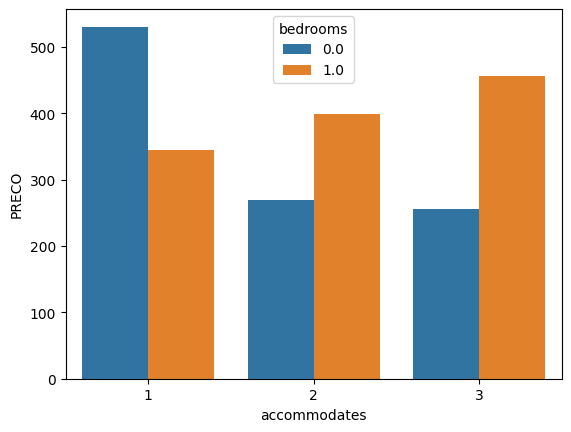

In [16]:
plt.figure()
sns.barplot(x='accommodates', y='PRECO', hue='bedrooms', data=df_media)
plt.show()

In [17]:
#Calculando pela mediana para valores mais fieis
pd.crosstab(df['accommodates'], df['bedrooms'], values=df['price'], aggfunc='median').round(2)

bedrooms,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,16.0,26.0,27.0
accommodates,,,,,,,,,,,,,,,,,,
1,159.0,139.0,199.0,124.0,92.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,201.0,233.0,279.0,252.5,340.0,279.0,475.5,NaN,NaN,NaN,225.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,213.0,246.0,369.0,426.5,171.0,NaN,207.0,112.0,NaN,NaN,NaN,2000.0,NaN,NaN,NaN,NaN,NaN,NaN
4,218.0,279.0,472.0,697.0,1100.0,60.0,NaN,NaN,NaN,NaN,200.0,NaN,NaN,NaN,NaN,NaN,178.0,NaN
5,225.0,276.0,449.5,684.0,469.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,440.5,257.0,492.0,755.0,1706.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,301.0,294.0,442.0,707.5,1291.0,27389.0,NaN,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,293.0,161.5,440.0,769.0,1386.0,3000.0,3400.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,507.0,420.0,774.0,1345.0,2631.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
#Aqui identifico que só há um imóvel que acomode 3 pessoas com 4 quartos
df[(df['bedrooms'] == 4) & (df['accommodates'] == 3)]['price'].min()

171.0

In [28]:
df[(df['bedrooms'] == 4) & (df['accommodates'] == 3)]['price'].max()

171.0

In [20]:
df_mediana = df_filtro.groupby(['accommodates', 'bedrooms']).agg(PRECO = ('price', 'median')).reset_index()
df_mediana

,accommodates,bedrooms,PRECO
0,1,0.0,159.0
1,1,1.0,139.0
2,2,0.0,201.0
3,2,1.0,233.0
4,3,0.0,213.0
5,3,1.0,246.0


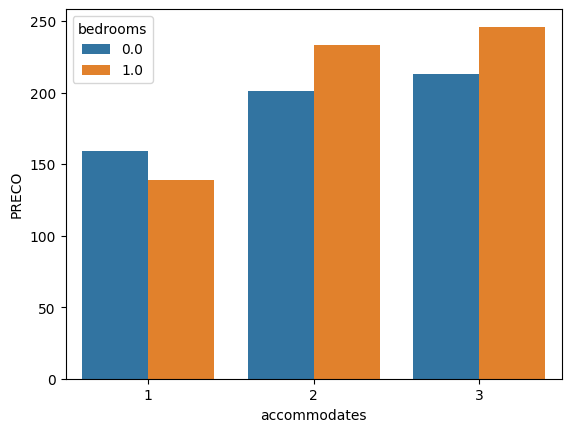

In [21]:
plt.figure()
df_mediana = df_mediana.sort_values('PRECO')

sns.barplot(x='accommodates', y='PRECO', hue='bedrooms', data=df_mediana)
plt.show()

In [22]:
familia_2_quartos = df[(df['accommodates'].between(3,5)) & (df['bedrooms'] == 2)]
print(f"Total de imóveis disponíveis para grupos entre 3 e 5 pessoas com 2 quartos: {len(familia_2_quartos)}")

Total de imóveis disponíveis para grupos entre 3 e 5 pessoas com 2 quartos: 3229


In [34]:
#Tabela de média de preços para grupos de 3-5 pessoas
df_filtro_grupo = df[(df['accommodates'].between(3, 5)) & (df['bedrooms'].isin([2, 3]))].copy()
df_media_grupo = df_filtro_grupo.groupby(['accommodates', 'bedrooms']).agg(PRECO = ('price', 'mean')).reset_index()
df_media_grupo

,accommodates,bedrooms,PRECO
0,3,2.0,527.388664
1,3,3.0,589.583333
2,4,2.0,739.148266
3,4,3.0,1016.645455
4,5,2.0,719.841772
5,5,3.0,1088.714286


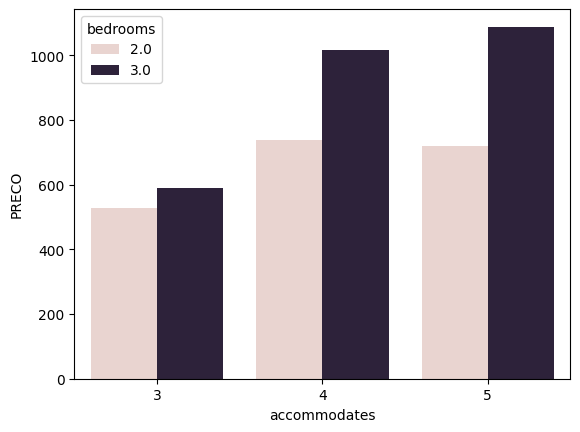

In [31]:
plt.figure()
sns.barplot(x='accommodates', y='PRECO', hue='bedrooms', data=df_media_grupo)
plt.show()

In [35]:
#Tabela de mediana de preços para grupos de 3-5 pessoas
df_mediana_grupo = df_filtro_grupo.groupby(['accommodates', 'bedrooms']).agg(PRECO = ('price', 'median')).reset_index()
df_mediana_grupo

,accommodates,bedrooms,PRECO
0,3,2.0,369.0
1,3,3.0,426.5
2,4,2.0,472.0
3,4,3.0,697.0
4,5,2.0,449.5
5,5,3.0,684.0


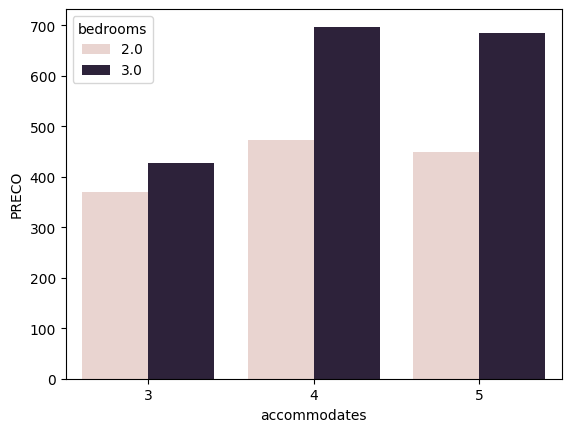

In [33]:
plt.figure()
sns.barplot(x='accommodates', y='PRECO', hue='bedrooms', data=df_mediana_grupo)
plt.show()

Para viajantes sozinhos, em dupla e até em trio de rápida estadia a taxa de preços é até favorável. Mas também é possível perceber que imóveis com 1 quarto que acomodem a mesma quantidade de pessoas não é tão distante a faixa de preços e pode ser até mais barato para 1 pessoa, do que um loft/estúdio.


Da mesma forma podemos avaliar que partindo do princípio que para viagens em família ou amigos (entre 3 e 5 pessoas), e que 2 quartos seria o mínimo de conforto, os preços tendem a variar muito de acordo com a quantidade de pessoas e de quartos, além de que há poucos imóveis nessa faixa de acomodações. Mas é possível perceber que a diferença entre 2 e 3 quartos específicamente para 3 pessoas, é pequena. O que pode ser uma boa escolha para mais conforto em grupos grandes.

In [23]:
#Criando dataframes separados para cda tipo de intenção de hospedagem
#Viagem 1-2 pessoas --- Quartos de 0-1
df_tipo1 = df[(df['accommodates'] <= 2) & (df['bedrooms'] <= 1)].copy()

In [24]:
#Viagem 3-5 pessoas --- Quartos mínimo=2
df_tipo2 = df[(df['accommodates'].between(3, 5)) & (df['bedrooms'] >= 2)].copy()

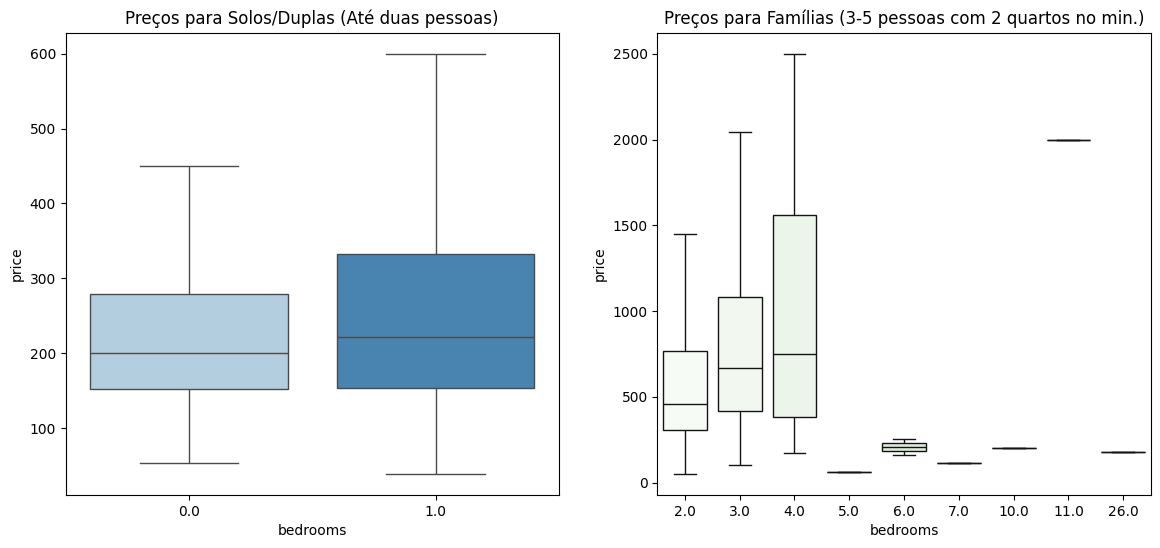

In [25]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='bedrooms', y='price', data=df_tipo1, showfliers=False, palette='Blues', hue='bedrooms', legend=False)
plt.title('Preços para Solos/Duplas (Até duas pessoas)')

plt.subplot(1, 2, 2)
sns.boxplot(x='bedrooms', y='price', data=df_tipo2, showfliers=False, palette='Greens', hue='bedrooms', legend=False)
plt.title('Preços para Famílias (3-5 pessoas com 2 quartos no min.)')

plt.show()

Os boxplots revelam que para viajentes do $tipo1$ não necessáriamente precisam optar por um loft/estúdio. Podem pelo mesmo preço ou um pouquinho a mais ter mais conforto tendo 1 quarto inteiro pra si.
<br></br>Ao mesmo tempo mostra que apesar de ter diferenças consideráveis, algumas opções ainda podem ser consideradas para viajantes do $tipo2$ que iriam pagar a mais por um imovel com 2 quartos, podem subir um pouco o valor para conseguir um pouco mais para 3 quartos (em até 3 pessoas).